In [ ]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns


In [77]:
df_original = pd.read_csv('../data/raw/dataset-6ab989b678d90892980305.csv')

In [78]:
df_original.describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


In [79]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CUST_ID                 8950 non-null   object 
 1   BALANCE                 8950 non-null   float64
 2   PURCHASES               8950 non-null   float64
 3   ONEOFF_PURCHASES        8950 non-null   float64
 4   INSTALLMENTS_PURCHASES  8950 non-null   float64
 5   CASH_ADVANCE            8950 non-null   float64
 6   CREDIT_LIMIT            8949 non-null   float64
 7   PAYMENTS                8950 non-null   float64
dtypes: float64(7), object(1)
memory usage: 559.5+ KB


In [80]:
df_original.isna().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

In [81]:
df_original.loc[df_original['CREDIT_LIMIT'].isna()]

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
5203,C15349,18.400472,0.0,0.0,0.0,186.853063,NaN,9.040017


In [82]:
# A summary table of missing values (count and percentage) per column, sorted in descending order.

missing = pd.DataFrame({
    "missing_count": df_original.isnull().sum(),
    "missing_percentage": (df_original.isnull().sum() / len(df_original) * 100).round(2)
})

missing = missing.sort_values("missing_count", ascending=False)
print(missing)

                        missing_count  missing_percentage
CREDIT_LIMIT                        1                0.01
CUST_ID                             0                0.00
PURCHASES                           0                0.00
BALANCE                             0                0.00
ONEOFF_PURCHASES                    0                0.00
INSTALLMENTS_PURCHASES              0                0.00
CASH_ADVANCE                        0                0.00
PAYMENTS                            0                0.00


In [83]:
df_clean = pd.read_csv('../data/processed/card_profiler_clean.csv')

ONEOFF_PURCHASES          10.044622
PURCHASES                  8.143969
INSTALLMENTS_PURCHASES     7.298823
PAYMENTS                   5.907465
CASH_ADVANCE               5.166323
BALANCE                    2.393270
CREDIT_LIMIT               1.522464
dtype: float64

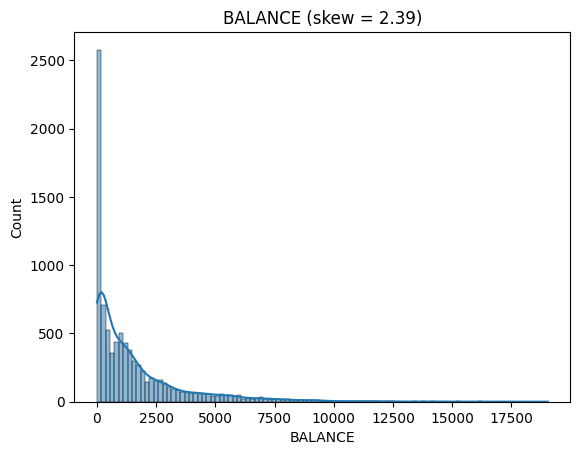

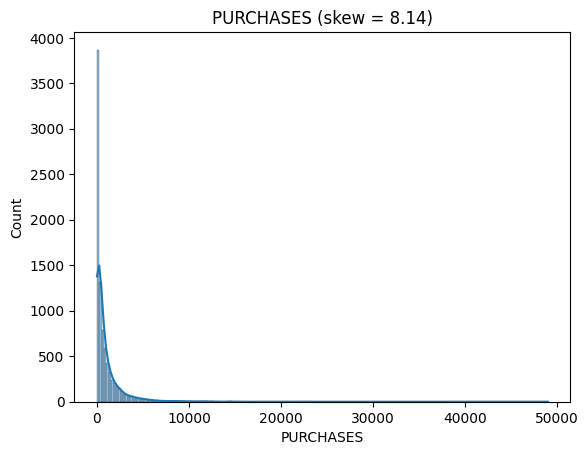

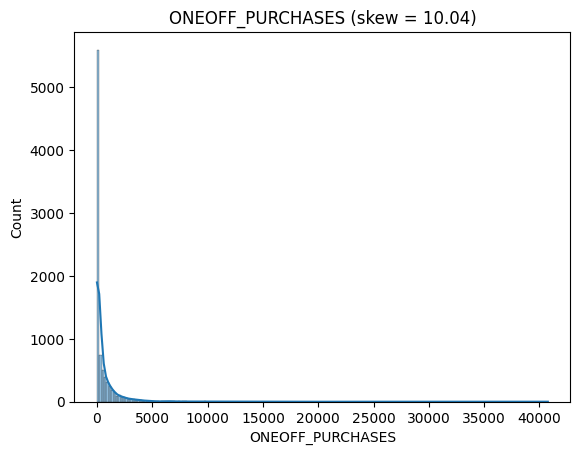

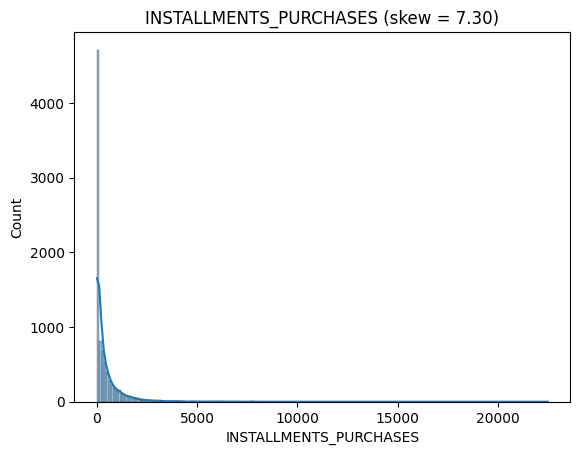

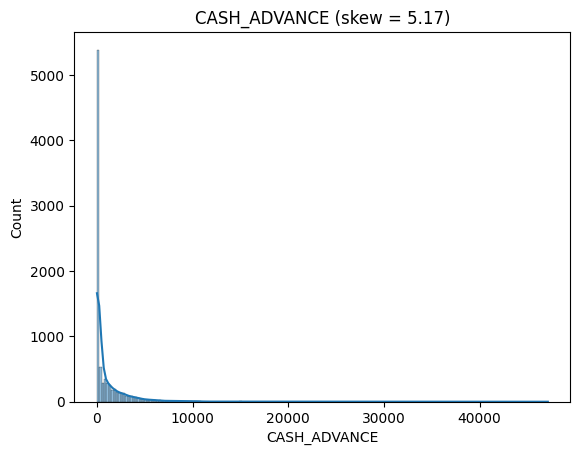

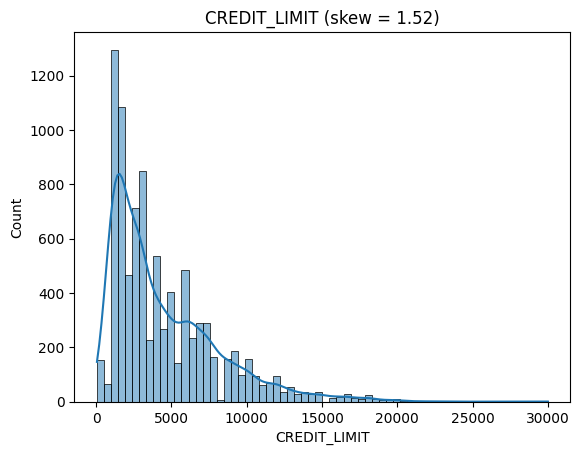

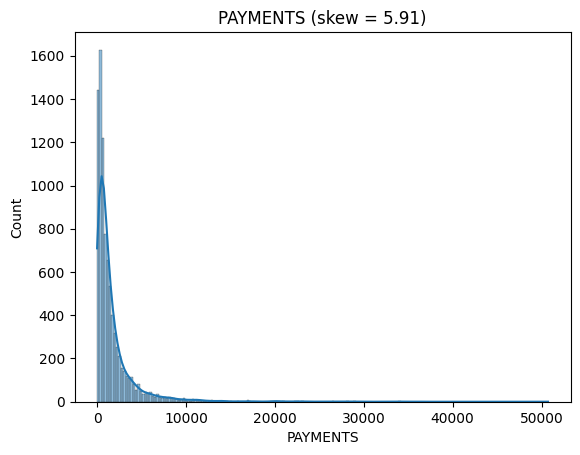

In [ ]:
# Histogram + KDE curve and skewness for each numeric column
# keep only numeric columns
df_clean = df_clean.drop(columns=["Unnamed: 0"])

columns_with_num = df_clean.select_dtypes(include='number').columns
# a function that loop through the columns and show the KDE plot
def show_hist_skew(df, columns):
    for i in columns:
        plt.figure()
        sns.histplot(df[i], kde=True)
        plt.title(f"{i} (skew = {df[i].skew():.2f})")

show_hist_skew(df_clean ,columns_with_num)
skew_table = df_clean[columns_with_num].skew().sort_values(ascending=False)
skew_table

Text(0.5, 1.0, 'Correlation between variables')

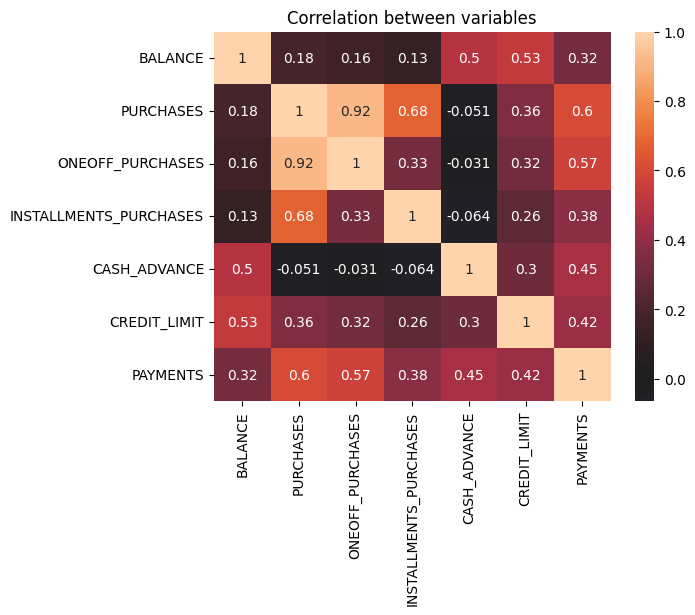

In [85]:
# Hitmap Correlation between variables

sns.heatmap(df_clean[columns_with_num].corr(), annot=True, center=0)
plt.title('Correlation between variables')

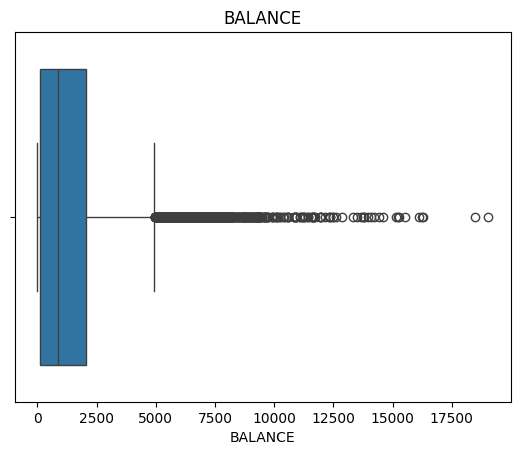

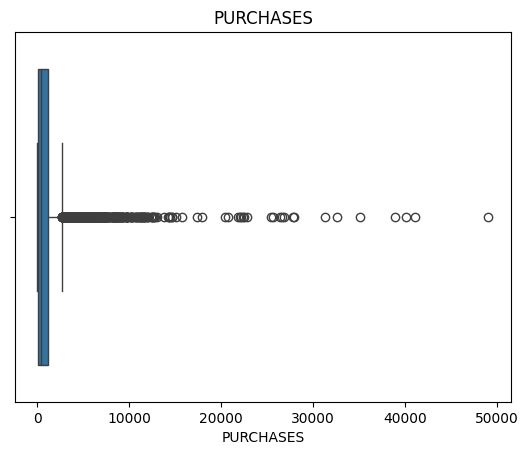

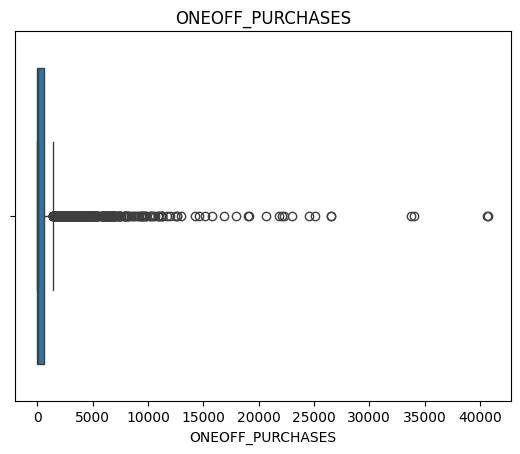

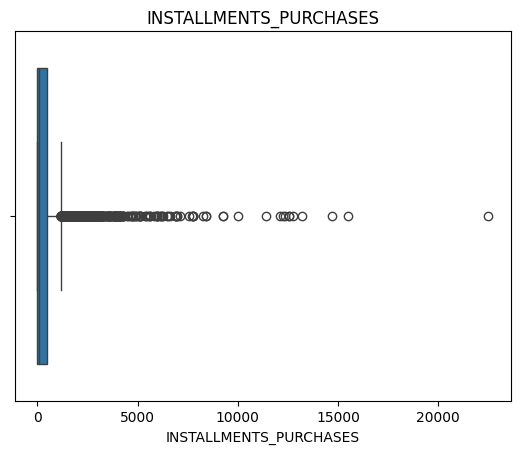

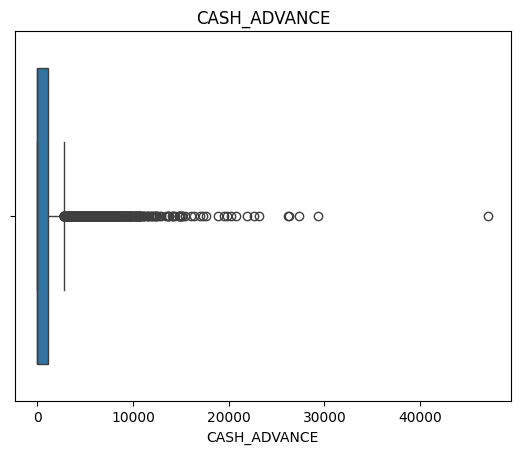

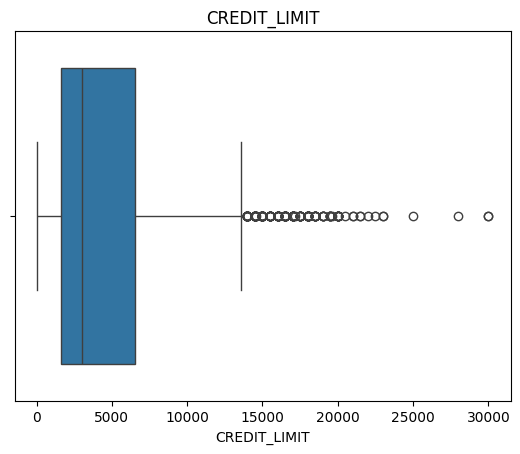

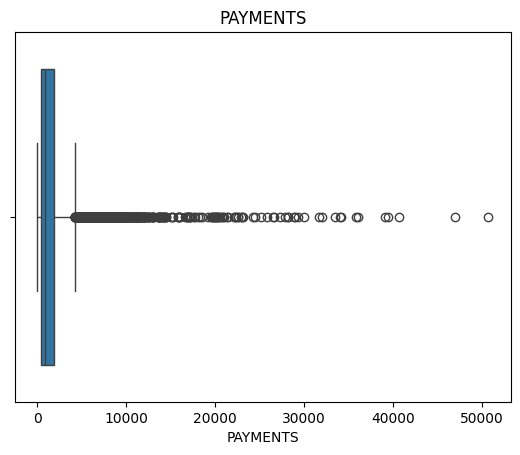

In [86]:

def call_boxplot(df, columns):
    for i in columns:
        plt.figure()
        sns.boxplot(x=df[i])
        plt.title(f"{i}")



call_boxplot(df_clean, columns_with_num)

In [87]:
# outliers


def outliers(df, columns):
    for i in columns:
        q1 = df[i].quantile(0.25)
        q3 = df[i].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        n_outliers = ((df[i] < lower) | (df[i] > upper)).sum()
        print(f"{i}: {n_outliers} outliers (bounds: {lower:.1f} to {upper:.1f})")


outliers(df_clean, columns_with_num)

BALANCE: 695 outliers (bounds: -2760.6 to 4943.4)
PURCHASES: 808 outliers (bounds: -1565.8 to 2715.7)
ONEOFF_PURCHASES: 1013 outliers (bounds: -866.7 to 1444.6)
INSTALLMENTS_PURCHASES: 867 outliers (bounds: -703.0 to 1171.6)
CASH_ADVANCE: 1030 outliers (bounds: -1670.8 to 2784.7)
CREDIT_LIMIT: 248 outliers (bounds: -5750.0 to 13850.0)
PAYMENTS: 808 outliers (bounds: -1893.7 to 4178.3)
